In [15]:
from hcipy import *
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import time
import os
import sys
import pandas as pd
import utils

set the telescope and optics pramaters

In [36]:
utils.check_dir
wavelength=1e-6
telescope_diameter=0.3
N=240
oversz=16.0/15.0
oversz*N
spider_w = 0.005         # [m]
D_obs =0.1       # [m]
eps = D_obs / telescope_diameter # central obscuration ratio
pupil_grid = make_pupil_grid(N*oversz, telescope_diameter * oversz)
ap_gen = make_obstructed_circular_aperture(telescope_diameter, eps, num_spiders=4, spider_width=spider_w)
ap = evaluate_supersampled(ap_gen, pupil_grid, 4) 
spatial_resolution=spatial_resolution = wavelength / telescope_diameter
num_airy_focal=5
focal_grid = make_focal_grid(q=4, num_airy=num_airy_focal, spatial_resolution=spatial_resolution)
prop = FraunhoferPropagator(pupil_grid, focal_grid)
aperture = circular_aperture(telescope_diameter)(pupil_grid)

/var/folders/fg/mh92bnm17tzb3j45vlzgdds40000gn/T/ipykernel_14887/3310267766.py:17: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(telescope_diameter)(pupil_grid)


In [49]:
fried_parameter = 0.2 # meter
outer_scale = 20 # meter
velocity = 10 # meter/sec


Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)

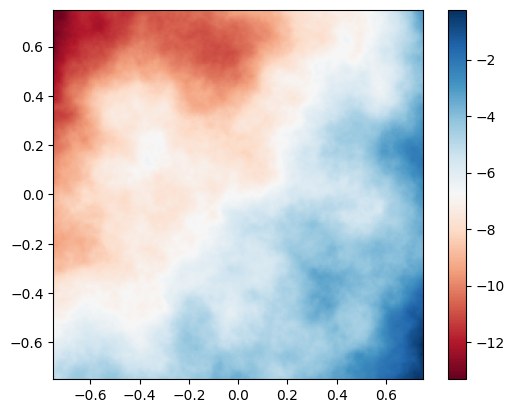

In [50]:
prop = FraunhoferPropagator(pupil_grid, focal_grid)
imshow_field(layer.phase_for(wavelength), cmap='RdBu')
plt.colorbar()
plt.show()

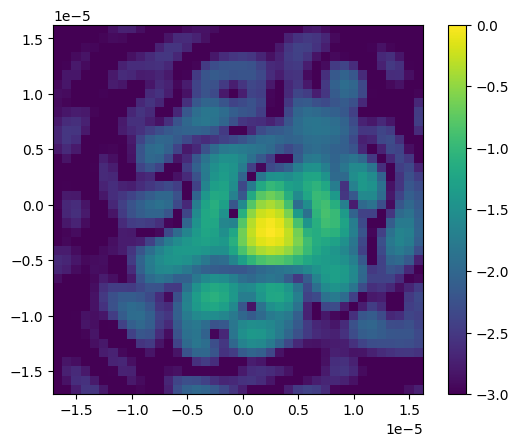

In [51]:

wf = Wavefront(aperture, wavelength)
img = prop(layer(wf))

imshow_field(np.log10(img.intensity / img.intensity.max()), vmin=-3)
plt.colorbar()
plt.show()

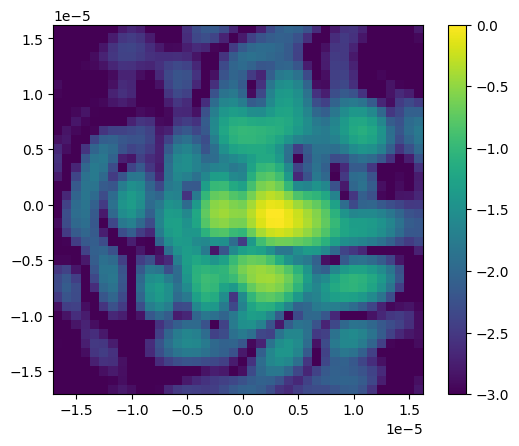

In [52]:
layer.t = 0.1 # sec

img = prop(layer(wf))

imshow_field(np.log10(img.intensity / img.intensity.max()), vmin=-3)
plt.colorbar()
plt.show()

In [72]:
pupil_grid = make_pupil_grid(256, 1.5)
prop = FraunhoferPropagator(pupil_grid, focal_grid)

pup = circular_aperture(1)(pupil_grid)

# Make multi-layer atmosphere
layers = make_standard_atmospheric_layers(pupil_grid, outer_scale)

atmos = MultiLayerAtmosphere(layers, scintilation=True)
print(atmos)
print("atmos: ",type([atmos]))
print("layers: ",type(layers[0]))

plt.figure(figsize=(5, 4))
anim = FFMpegWriter('atmospheric_turbulence.mp4', framerate=5)
t_end = 1
n = 51
for t in np.linspace(0, t_end, n):
    atmos.t = t
    phase_screen_phase = layers.phase_for(wavelength) # in radian
    phase_screen_opd = phase_screen_phase * (wavelength / (2 * np.pi)) * 1e6 # in um

    plt.clf()
    plt.suptitle('Time %.3f s' % t)

    plt.subplot(1,1,1)
    plt.title('Turbulent wavefront [$\\mu$m]')
    imshow_field(phase_screen_opd, vmin=-6, vmax=6, cmap='RdBu')
    plt.colorbar()

    anim.add_frame()

plt.close()
anim.close()

# Show created animation
anim

/var/folders/fg/mh92bnm17tzb3j45vlzgdds40000gn/T/ipykernel_14887/837489031.py:4: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  pup = circular_aperture(1)(pupil_grid)
/var/folders/fg/mh92bnm17tzb3j45vlzgdds40000gn/T/ipykernel_14887/837489031.py:7: DeprecationWarning: make_standard_atmospheric_layers is deprecated. Its new name is make_mauna_kea_atmospheric_layers.
  layers = make_standard_atmospheric_layers(pupil_grid, outer_scale)


atmos:  <class 'list'>
layers:  <class 'hcipy.atmosphere.infinite_atmospheric_layer.InfiniteAtmosphericLayer'>


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/hcipy/atmosphere/atmospheric_model.py:174: UserWarning: Please use the correct spelling for scintillation.
  warnings.warn('Please use the correct spelling for scintillation.')


AttributeError: 'list' object has no attribute 'phase_for'

<Figure size 500x400 with 0 Axes>

670084.4608303468


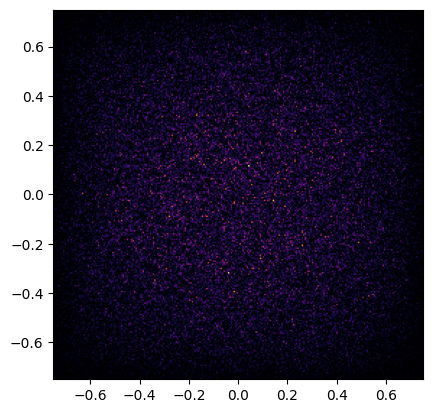

In [64]:
# Set the seeing parameters and reset
atmos.Cn_squared = Cn_squared_from_fried_parameter(0.1, 500-9)
atmos.reset()
print(atmos.Cn_squared)
# Use super-Gaussian to avoid edge effects
p = np.exp(-(pupil_grid.as_('polar').r/0.68)**20)
wf = atmos(Wavefront(Field(p, pupil_grid), 2e-6))

# Show scintillation field
imshow_field(wf.intensity , cmap='inferno')
plt.show()

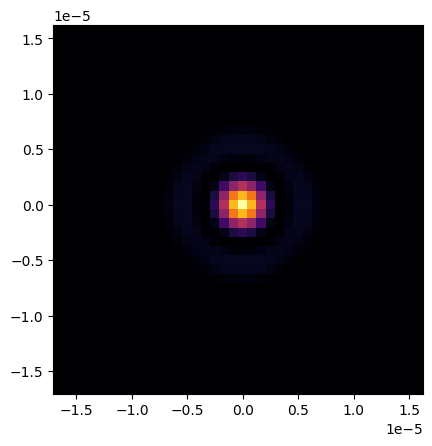

In [60]:
wf11=Wavefront(ap,wavelength)
imshow_field(prop(wf11).intensity , cmap='inferno')



NameError: name 'atoms' is not defined

<Figure size 500x400 with 0 Axes>